In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
import h5py

In [17]:
def readComplexVec_hdf5(file_name, dataset_name):
    # Open the HDF5 file
    with h5py.File(file_name, 'r') as hdf_file:
        # Check if the dataset exists
        if dataset_name in hdf_file:
            # Read the dataset
            data = hdf_file[dataset_name][:]
            # Convert to numpy complex array if it's a complex dataset
            if np.issubdtype(data.dtype, np.complexfloating):
                data = np.array(data, dtype=np.complex128)
            print(f"Data in dataset '{dataset_name}':\n{data}")
            return data
        else:
            print(f"Dataset '{dataset_name}' not found in file '{file_name}'")

def readVec_hdf5(file_name, dataset_name):
    # Open the HDF5 file
    with h5py.File(file_name, 'r') as hdf_file:
        # Check if the dataset exists
        if dataset_name in hdf_file:
            # Read the dataset
            data = hdf_file[dataset_name][:]
            # Convert to numpy complex array if it's a complex dataset
            if np.issubdtype(data.dtype, np.double):
                data = np.array(data, dtype=np.double)
            # Convert to numpy complex array if it's a complex dataset
            if np.issubdtype(data.dtype, np.single):
                data = np.array(data, dtype=np.single)
            print(f"Data in dataset '{dataset_name}':\n{data}")
            return data
        else:
            print(f"Dataset '{dataset_name}' not found in file '{file_name}'")


def plotFullSignal(complex_data,title):
    real_part = np.real(complex_data)
    imaginary_part = np.imag(complex_data)

    # Plot the real and imaginary parts
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(real_part, label='Real Part')
    plt.title('Real Part of Signal')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')

    plt.subplot(2, 1, 2)
    plt.plot(imaginary_part, label='Imaginary Part', color='orange')
    plt.title(title)
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')




    plt.tight_layout()
    plt.show()

def plotMagPhase(complex_data):
    real_part = np.real(complex_data)
    imaginary_part = np.imag(complex_data)
    mag=np.sqrt(real_part**2+imaginary_part**2)
    phase=np.arctan(imaginary_part,real_part)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(mag, label='Mag')
    plt.subplot(2, 1, 2)
    plt.plot(phase, label='Phase', color='orange')
    
def compareInPhase(complexA, complexB, startIndex, endIndex):
    plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(np.real(complexA)[startIndex:endIndex])
    plt.title('A')
    plt.subplot(2, 1, 2)
    plt.plot(np.real(complexB)[startIndex:endIndex])
    plt.title('B')
    plt.show()

def compareTxRxChannels(complexA, complexB, startIndex, endIndex):
    plt.figure(figsize=(14,6))
    plt.subplot(2, 2, 1)
    plt.plot(np.real(complexA)[startIndex:endIndex])
    plt.ylabel("Sig A")
    plt.ylabel("I")    
    plt.subplot(2, 2, 2)
    plt.plot(np.imag(complexA)[startIndex:endIndex])
    plt.ylabel("Q")
    plt.subplot(2, 2, 3)
    plt.plot(np.real(complexB)[startIndex:endIndex])
    plt.ylabel("Sig B")
    plt.ylabel("I")
    plt.subplot(2, 2, 4)
    plt.plot(np.imag(complexB)[startIndex:endIndex])
    plt.ylabel("Q")
    plt.show()

def plotVector(signal, startIndex, endIndex, title ):
    plt.figure(figsize=(14,6))
    plt.plot(signal[startIndex:endIndex])
    plt.title(title)
    return

def plotFFT(complex_data, samplingRate):
    N=len(complex_data)
    fft_result = np.fft.fft(complex_data)
    freqs = np.fft.fftfreq(N, d=1/samplingRate)
    fft_flipped = np.fft.fftshift(fft_result)
    freqs_flipped = np.fft.fftshift(freqs)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("FFT Result")
    plt.plot(freqs/1e3, np.abs(fft_result)/np.size(fft_result))
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.plot(freqs/1e3, np.angle(fft_result,True))
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("Phase")

        

# Single Frequency

In [3]:
pathToFile="../build/samples.h5"
transmitData=readComplexVec_hdf5(pathToFile,"transmit")
receivedData=readComplexVec_hdf5(pathToFile,"received")
singleChannelRec=readVec_hdf5(pathToFile,"singleChannel")
mixedSignalI=readVec_hdf5(pathToFile,"mixedSignalI")
mixedSignalQ=readVec_hdf5(pathToFile,"mixedSignalQ")


OSError: Unable to synchronously open file (file signature not found)

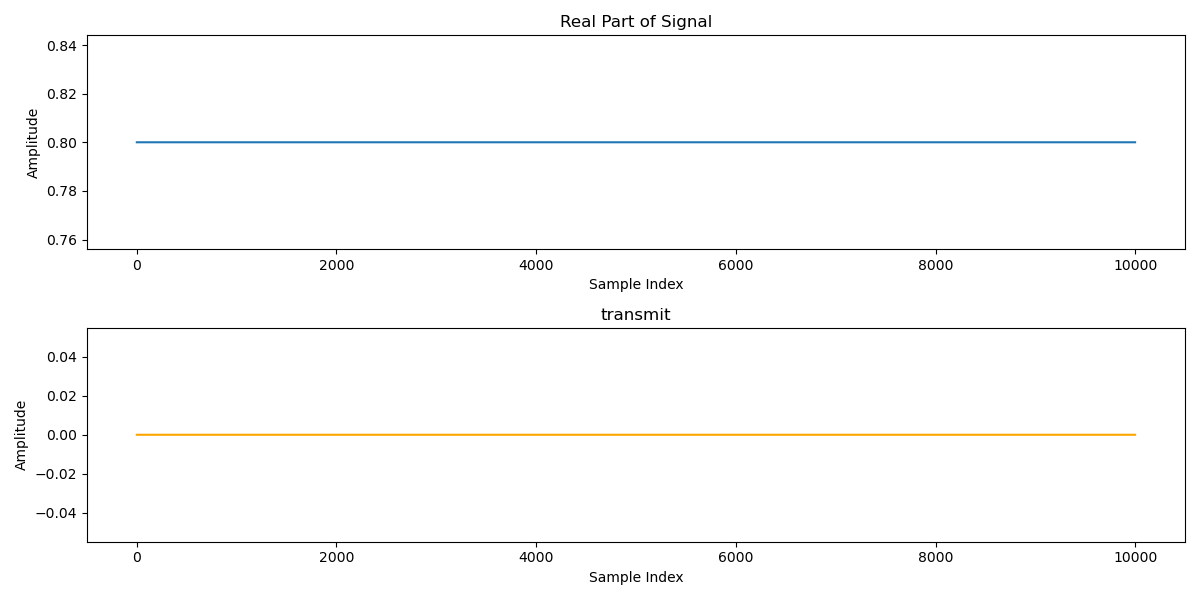

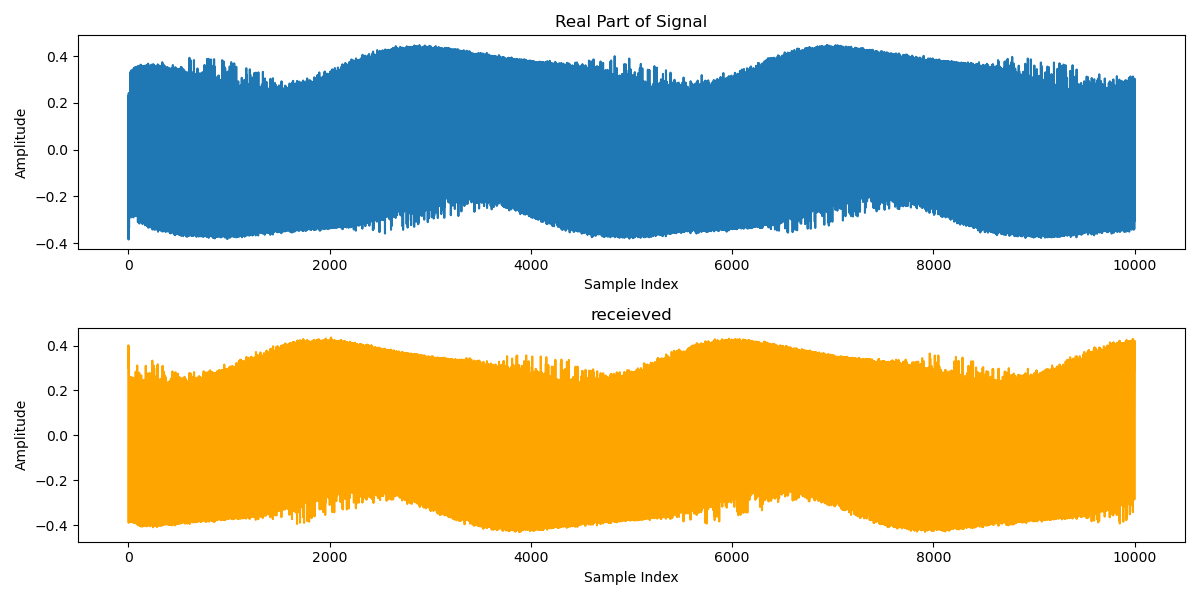

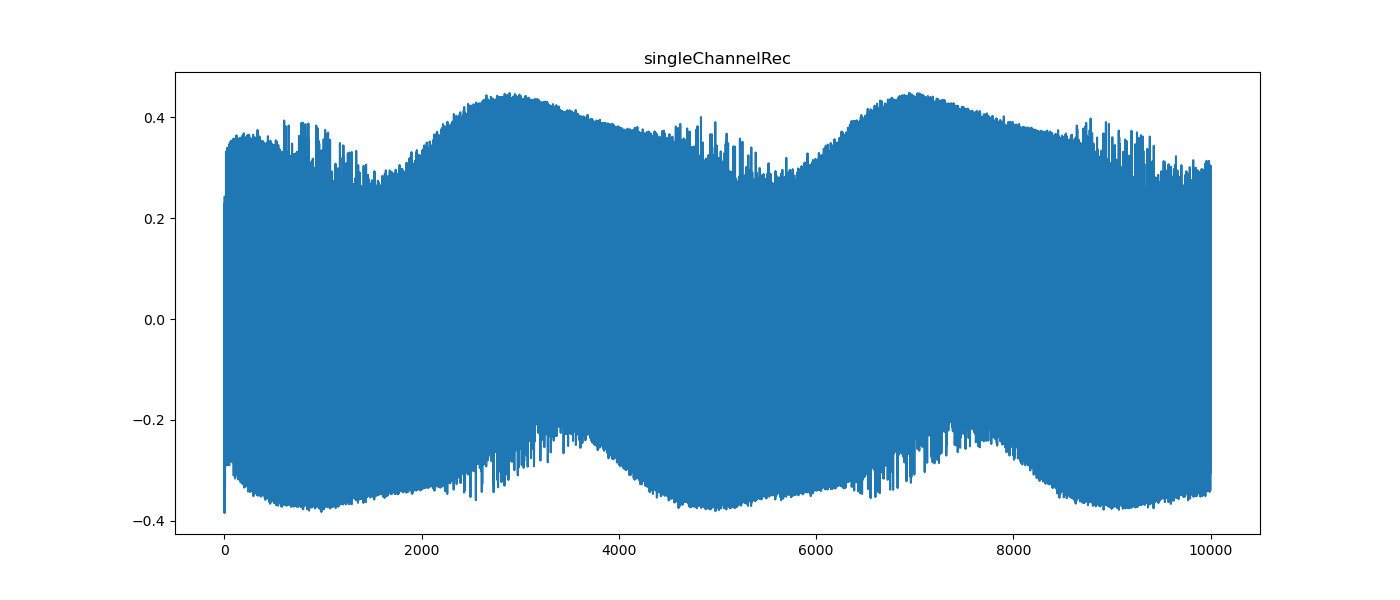

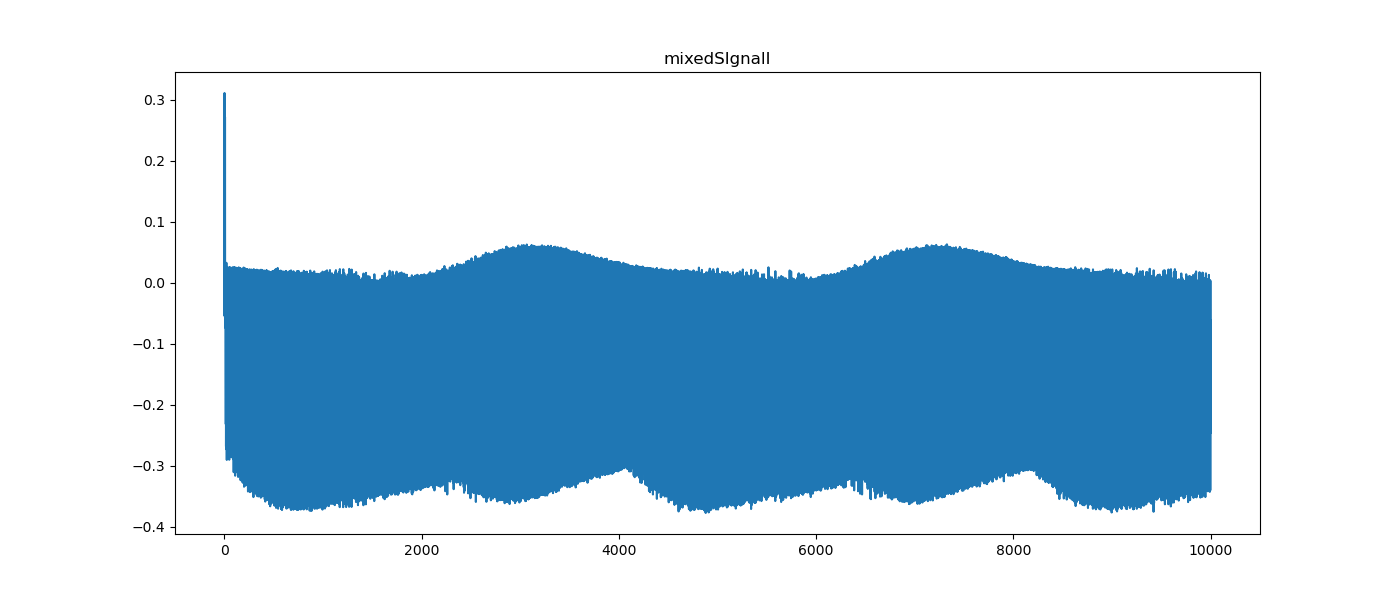

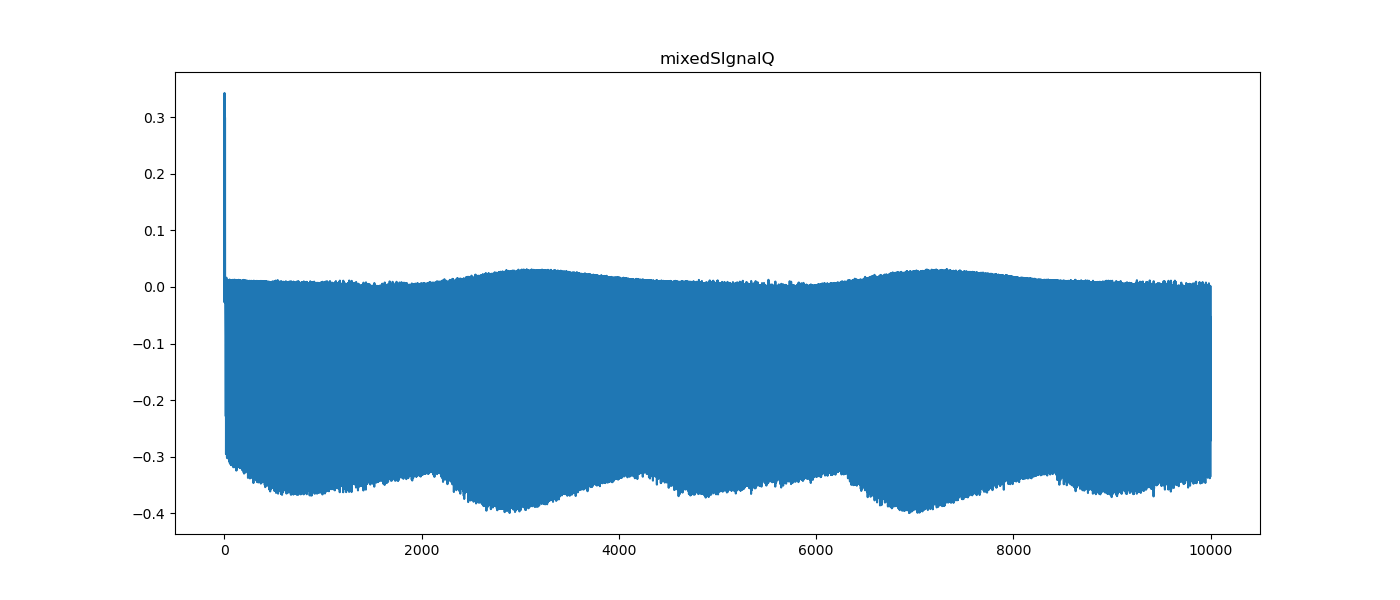

In [ ]:
plotFullSignal(transmitData,"transmit")
plotFullSignal(receivedData,"receieved")
plotVector(singleChannelRec,0,np.size(singleChannelRec),"singleChannelRec")
plotVector(mixedSignalI,0,np.size(mixedSignalI),"mixedSIgnalI")
plotVector(mixedSignalQ,0,np.size(mixedSignalQ),"mixedSIgnalQ")





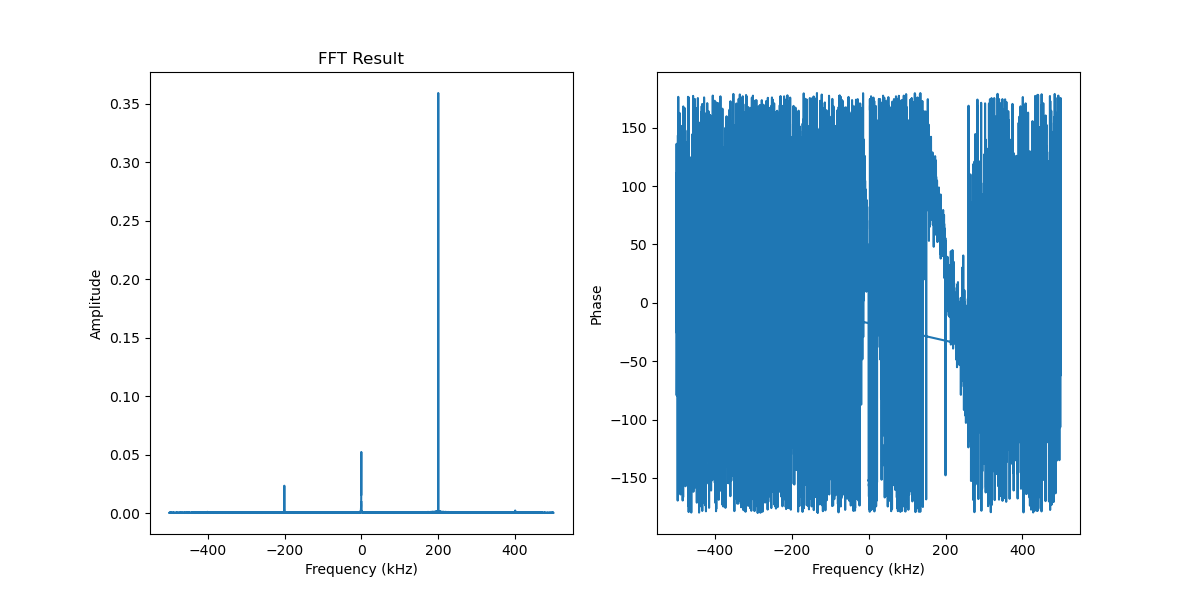

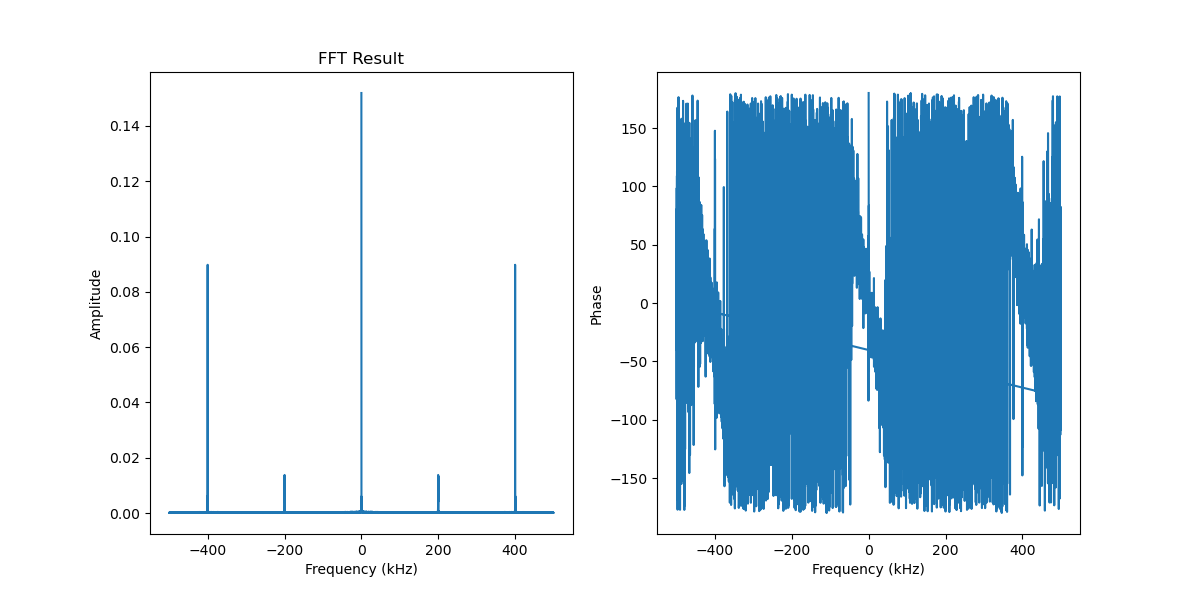

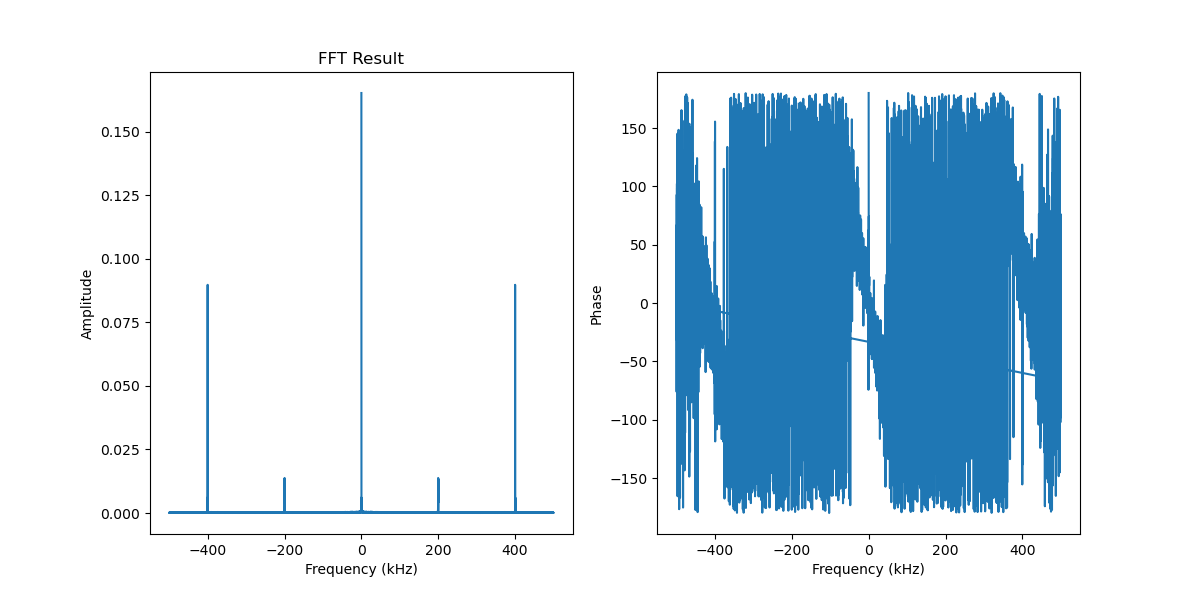

In [ ]:
plotFFT(receivedData,1e6)
plotFFT(mixedSignalI,1e6)
plotFFT(mixedSignalQ,1e6)



#  Sweep of Frequencies


Data in dataset 'sweep':
[ 3.40947673e-02-0.01005362j  5.08680941e-03+0.0016166j
 -6.37838779e-05-0.00709521j  6.31826533e-04-0.00316698j
  3.29480310e-02-0.01541549j  3.00431183e-03+0.0019835j
  1.67211399e-03-0.00262948j  2.16068622e-03-0.00858571j
  3.29101269e-02-0.01438921j  1.03876152e-02+0.00109864j
 -1.62404720e-03-0.00182303j  1.93869394e-03-0.00575547j
  3.29409202e-02-0.02734353j  5.29305409e-03-0.00211842j
 -2.12815340e-03-0.00158486j  2.08170409e-03-0.00448654j
  3.21745982e-02-0.02143901j  3.31886091e-02-0.01272861j
  3.32369811e-02-0.00878518j  3.30172167e-02-0.01312513j
  3.26395795e-02-0.01702297j  3.31391080e-02-0.0044472j
  3.28657529e-02-0.01021863j  3.27537801e-02-0.01761533j
  3.29064647e-02-0.0183187j   3.28359972e-02-0.00756699j
  3.28182354e-02-0.01020896j  3.25176577e-02-0.0116646j
  3.25999664e-02-0.00855684j  3.25115540e-02-0.01655851j
  3.22432650e-02-0.02306071j  3.23127559e-02-0.01072738j
  3.23392765e-02-0.0148104j   3.25345040e-02-0.0145986j
  3.2598165

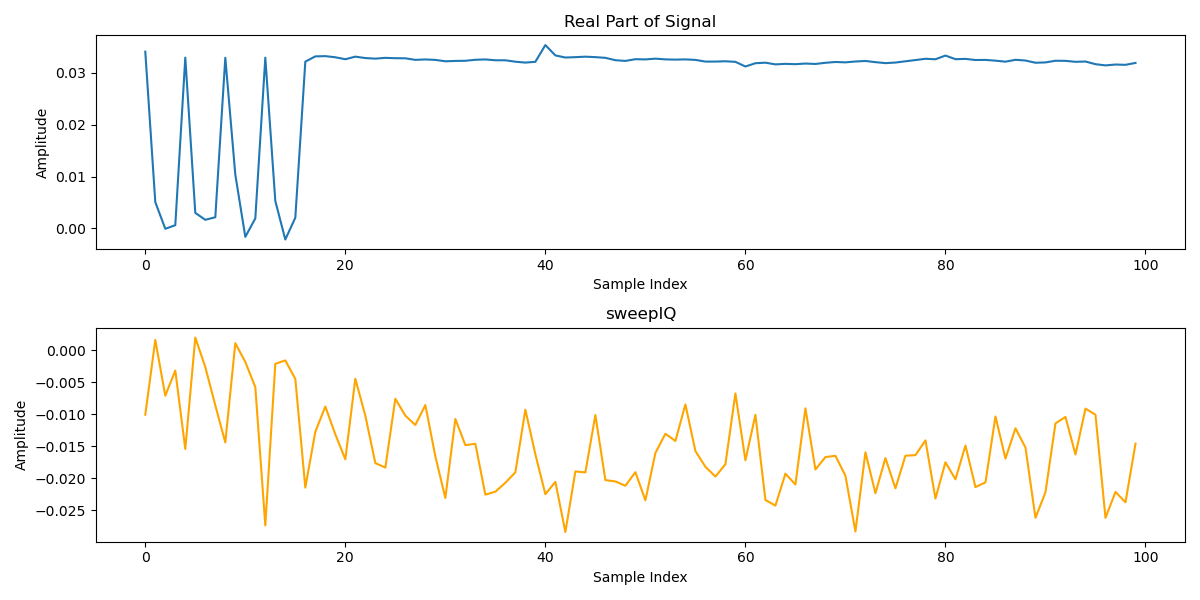

In [4]:
pathToSweepFile="../build/temp.h5"
sweepIQ=readComplexVec_hdf5(pathToSweepFile,"sweep")
plotFullSignal(sweepIQ,"sweepIQ")


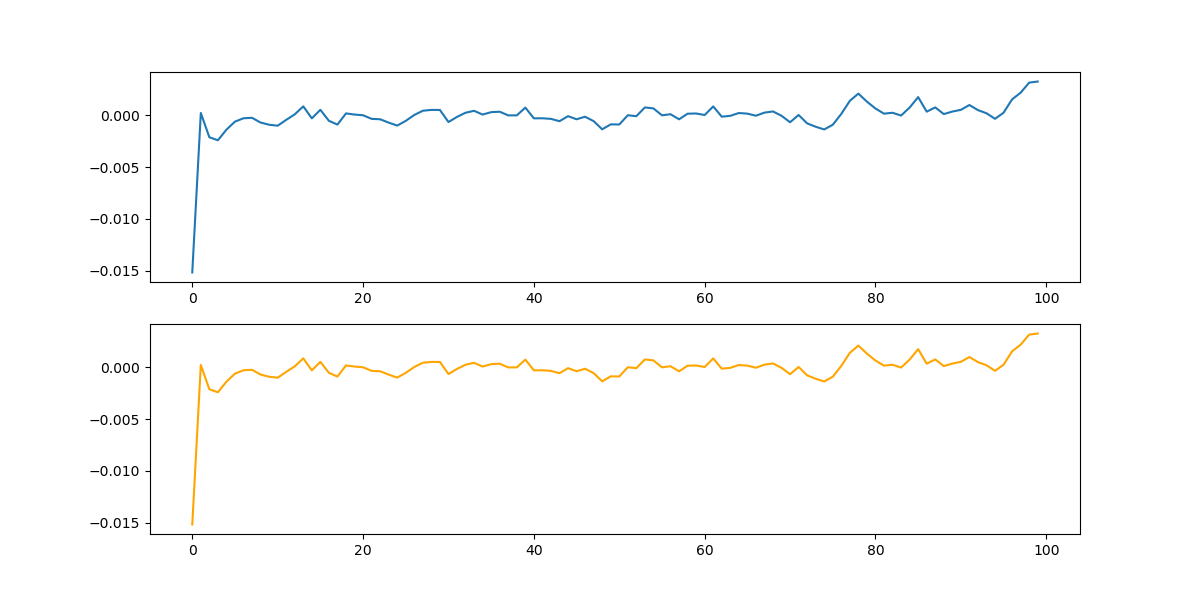

In [19]:
td=np.fft.ifft(sweepIQ)
df=5e6
N=5000
f0=400e6
lowerbound=int(f0/df)
manipFreqAxis=np.zeros(N,np.complex128)

#manipFreqAxis[lowerbound:lowerbound+np.size(sweepIQ[0])]=sweepIQ
#plotFullSignal(td,"test")
plotMagPhase(td)